In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

In [ ]:
# Load data 
DATA_DIR = Path(r"C:\Users\Admin\Documents\3. University\2. UOA\Sem2_2025_CV\A3\mvtec_anomaly_detection")

records = []
for obj_dir in sorted(DATA_DIR.iterdir()):
    if not obj_dir.is_dir():
        continue
    test_dir = obj_dir / "test"
    if not test_dir.exists():
        continue
    for defect_dir in sorted(test_dir.iterdir()):
        if not defect_dir.is_dir() or defect_dir.name == "good":
            continue
        count = len(list(defect_dir.glob("*.*")))
        if count > 0:
            records.append({"object": obj_dir.name, "defect_type": defect_dir.name, "count": count})

df = pd.DataFrame(records)
print(f"Total defect images : {df['count'].sum()}")
print(f"Objects             : {df['object'].nunique()}")
print(f"Unique defect types : {df['defect_type'].nunique()}")
df.head()

Total defect images : 1258
Objects             : 15
Unique defect types : 48


,object,defect_type,count
0,bottle,broken_large,20
1,bottle,broken_small,22
2,bottle,contamination,21
3,cable,bent_wire,13
4,cable,cable_swap,12


## 1. Bar Chart - Total Defects per Object

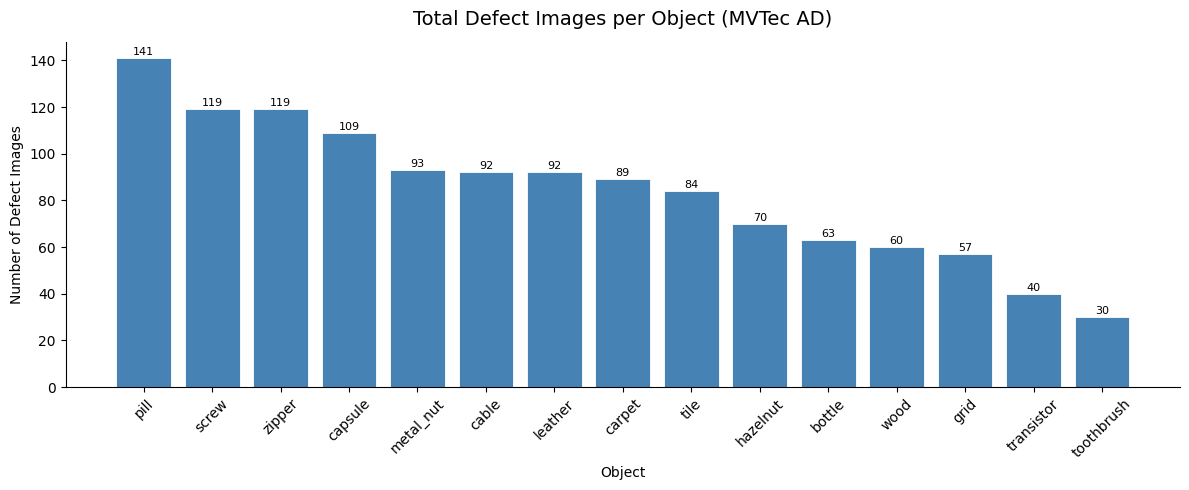

In [3]:
obj_totals = df.groupby("object")["count"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(obj_totals.index, obj_totals.values, color="steelblue", edgecolor="white", linewidth=0.6)

for bar, val in zip(bars, obj_totals.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(val), ha="center", va="bottom", fontsize=8)

ax.set_title("Total Defect Images per Object (MVTec AD)", fontsize=14, pad=12)
ax.set_xlabel("Object")
ax.set_ylabel("Number of Defect Images")
ax.tick_params(axis="x", rotation=45)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("defects_per_object.png", dpi=150)
plt.show()

## 2.  Heatmap - Defect Count by Object × Defect Type

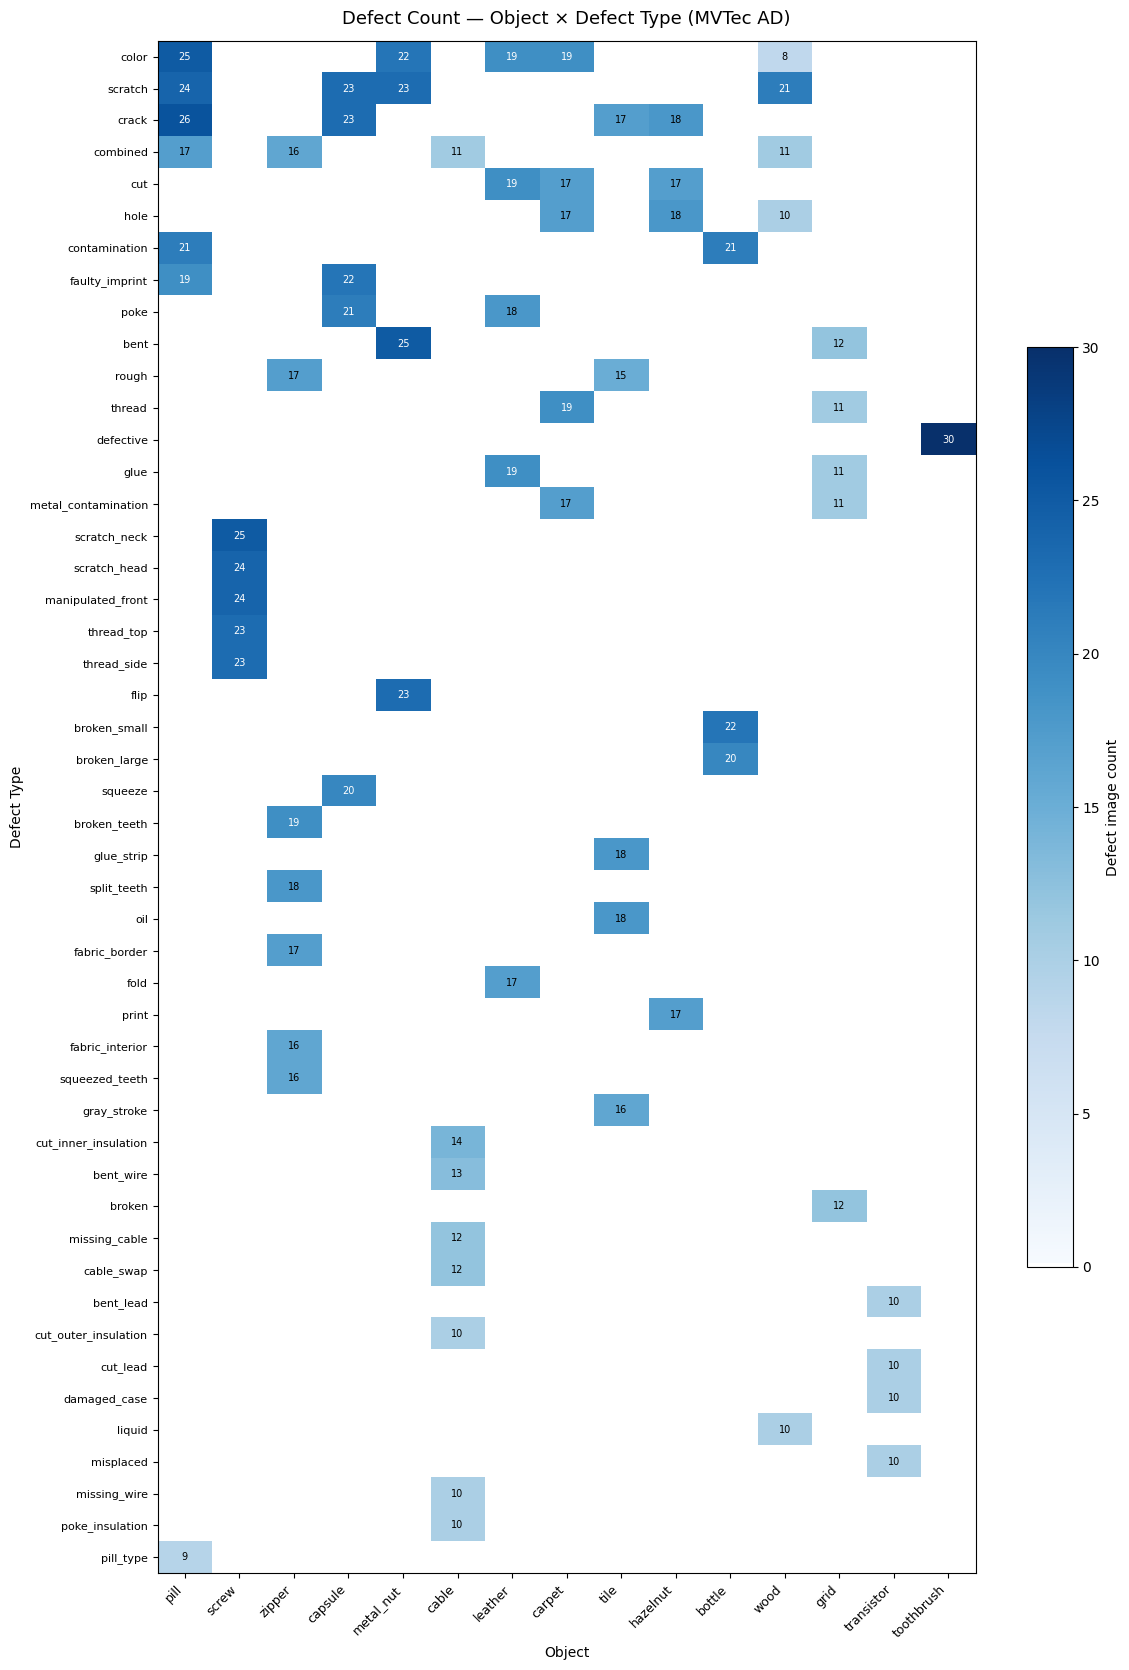

In [6]:
# Pivot: rows = defect_type, columns = object (ordered by total desc)
obj_order = df.groupby("object")["count"].sum().sort_values(ascending=False).index
pivot = (
    df.pivot_table(index="defect_type", columns="object", values="count", aggfunc="sum")
    .fillna(0)
    [obj_order]
)

# Sort defect types by total count descending
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

data = pivot.values.astype(float)

# Custom colormap: white for 0, then Blues
base_cmap = plt.get_cmap("Blues")
colors_list = [(1, 1, 1)] + [base_cmap(i / 255) for i in range(1, 256)]
cmap = mcolors.LinearSegmentedColormap.from_list("white_Blues", colors_list)

fig, ax = plt.subplots(figsize=(max(10, len(obj_order) * 0.8), max(8, len(pivot) * 0.35)))
im = ax.imshow(data, aspect="auto", cmap=cmap)

# Axes labels
ax.set_xticks(range(len(obj_order)))
ax.set_xticklabels(obj_order, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index, fontsize=8)

# Annotate cells with count (skip zeros)
for r in range(data.shape[0]):
    for c in range(data.shape[1]):
        val = int(data[r, c])
        if val > 0:
            text_color = "white" if data[r, c] > data.max() * 0.6 else "black"
            ax.text(c, r, str(val), ha="center", va="center", fontsize=7, color=text_color)

plt.colorbar(im, ax=ax, label="Defect image count", shrink=0.6)
ax.set_title("Defect Count — Object × Defect Type (MVTec AD)", fontsize=13, pad=12)
ax.set_xlabel("Object")
ax.set_ylabel("Defect Type")

plt.tight_layout()
plt.savefig("heatmap_defects.png", dpi=150, bbox_inches="tight")
plt.show()